<a href="https://colab.research.google.com/github/njwbilll/Tugas-3_Practical-Linear-Algebra-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/08_Eigendecomposition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 8: Eigendecomposition

**Referensi:** Practical Linear Algebra for Data Science (Mike X Cohen)

***

## Ringkasan Chapter

Eigendecomposition adalah proses menguraikan matriks menjadi komponen komponen fundamentalnya: vektor eigen (eigenvectors) dan nilai eigen (eigenvalues). Dalam dunia data science, ini bukan sekadar manipulasi angka, melainkan cara kita menemukan sumbu utama dari varians data.

Secara geometris, vektor eigen adalah arah di mana transformasi linear hanya melakukan perentangan atau penyusutan tanpa mengubah orientasi, sementara nilai eigen menentukan besaran perentangan atau penyusutan tersebut.

### Topik yang Dibahas:
1. Konsep Dasar Vektor Eigen dan Nilai Eigen
2. Properti Matematis Matriks Eigen
3. Eigendecomposition pada Matriks Simetris
4. Aplikasi Eigendecomposition dalam Reduksi Dimensi


***
## Setup: Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as LA

print("Modul aljabar linear berhasil dimuat.")


Modul aljabar linear berhasil dimuat.


***
## 1. Definisi Matematis Vektor Eigen

### Penjelasan Teori

Sebuah vektor eigen v dari matriks persegi A adalah vektor yang tidak berubah arahnya ketika dikalikan dengan matriks tersebut. Persamaannya adalah:
A v = lambda v

Di mana:
* A adalah matriks persegi.
* v adalah vektor eigen.
* lambda (eigenvalue) adalah skalar yang memperbesar atau memperkecil vektor v.

Jika kita memiliki matriks A, kita dapat mencari pasangan nilai dan vektor eigennya menggunakan fungsi `LA.eig` dari NumPy.

In [2]:
# Membuat matriks persegi 2x2 yang sederhana
A = np.array([[1, 2],
              [2, 1]])

# Menghitung eigenvalue dan eigenvector
evals, evecs = LA.eig(A)

print("Nilai Eigen (Eigenvalues):", evals)
print("Vektor Eigen (Eigenvectors):\n", evecs)

# Verifikasi: Apakah A v = lambda v?
v = evecs[:, 0] # Ambil vektor eigen pertama
lambda_val = evals[0]

sisi_kiri = A @ v
sisi_kanan = lambda_val * v

print("\nUji validasi (A @ v):", sisi_kiri)
print("Uji validasi (lambda * v):", sisi_kanan)


Nilai Eigen (Eigenvalues): [ 3. -1.]
Vektor Eigen (Eigenvectors):
 [[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Uji validasi (A @ v): [2.12132034 2.12132034]
Uji validasi (lambda * v): [2.12132034 2.12132034]


***
## 2. Visualisasi Geometris Eigendecomposition

### Penjelasan Teori

Eigendecomposition membantu kita memvisualisasikan bagaimana transformasi matriks bekerja. Matriks A di atas meregangkan ruang dua dimensi. Jika kita menggambar vektor eigen tersebut, kita akan melihat bahwa arah vektor tidak bergeser, melainkan hanya memanjang sesuai dengan nilai eigennya.

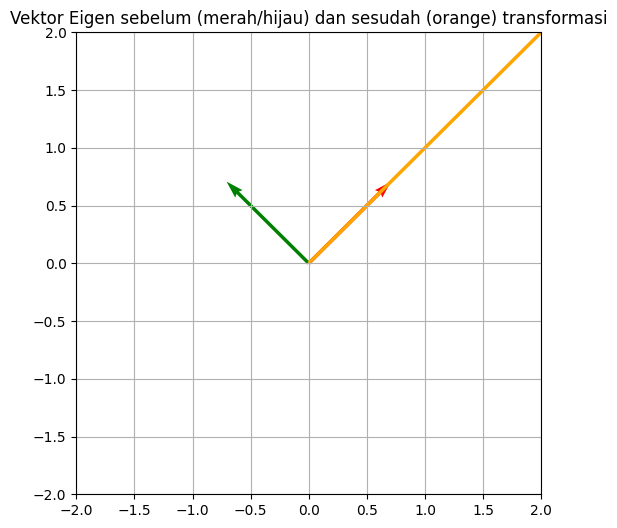

In [3]:
def plot_vector(vector, color='blue'):
    plt.quiver(0, 0, vector[0], vector[1], angles='xy', scale_units='xy', scale=1, color=color)

plt.figure(figsize=(6, 6))
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)

# Plot vektor eigen asli
plot_vector(evecs[:, 0], color='red')
plot_vector(evecs[:, 1], color='green')

# Plot hasil transformasi A @ v
plot_vector(A @ evecs[:, 0], color='orange')
plt.title('Vektor Eigen sebelum (merah/hijau) dan sesudah (orange) transformasi')
plt.show()


***
## 3. Aplikasi: Menemukan Sumbu Utama

### Penjelasan Teori

Dalam konteks data science, kita sering menerapkan eigendecomposition pada matriks kovarians. Karena matriks kovarians bersifat simetris, vektor vektor eigennya akan selalu saling tegak lurus (ortogonal). Sumbu utama inilah yang digunakan dalam algoritma PCA untuk menyederhanakan data dari banyak dimensi menjadi dimensi yang lebih rendah tanpa kehilangan banyak informasi.

Contoh di bawah menunjukkan bagaimana nilai eigen merepresentasikan jumlah varians yang ditangkap oleh setiap komponen utama.

In [4]:
# Membuat matriks kovarians simetris buatan
C = np.array([[4, 2],
              [2, 3]])

evals, evecs = LA.eig(C)

print("Varians yang ditangkap oleh masing-masing sumbu utama:", evals)
print("Arah sumbu utama (Vektor Eigen):\n", evecs)

# Proporsi varians
proporsi = evals / np.sum(evals)
print("\nPersentase informasi pada tiap sumbu:", np.round(proporsi * 100, 2), "persen")


Varians yang ditangkap oleh masing-masing sumbu utama: [5.56155281 1.43844719]
Arah sumbu utama (Vektor Eigen):
 [[ 0.78820544 -0.61541221]
 [ 0.61541221  0.78820544]]

Persentase informasi pada tiap sumbu: [79.45 20.55] persen
